In [ ]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

In [ ]:
using LinearAlgebra
using ForwardDiff
using PyPlot
using LaTeXStrings
using JupyterFormatter
import SymPy
enable_autoformat()
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "Times New Roman")
PyPlot.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

In [ ]:
# continuous time system
A_c = [0 1; 0 0];
B_c = [0; 1];

In [165]:
# derive discrete time system using matrix exponential
h_sym = SymPy.Sym("h")
D_sym = SymPy.exp([A_c B_c; 0 0 0] * h_sym)

h = 0.1
D = SymPy.N(D_sym.subs(h_sym, h))

A = D[1:2, 1:2]
B = D[1:2, 3]

2-element Vector{Real}:
 0.005000000000000001
 0.1

In [166]:
n = size(A)[2]  # number of states
m = length(size(B)) == 1 ? 1 : size(B)[2]  # number of controls
t_final = 5.0  # final time (try larger values, superlinear in computation complexity increase)
t_history = Array(0:h:t_final)
N = length(t_history)  # number of time steps

51

In [167]:
# initial conditions
x0 = [1.0; 0]

2-element Vector{Float64}:
 1.0
 0.0

In [168]:
# cost weights
Q = 1.0 * I(2)
R = 0.1  # try larger values
Q_N = 1.0 * I(2)

2×2 Diagonal{Float64, Vector{Float64}}:
 1.0   ⋅ 
  ⋅   1.0

In [169]:
function J(x_history, u_history)
    cost = 0.5 * x_history[:, end]' * Q_N * x_history[:, end]
    for k = 1:(N-1)
        cost +=
            0.5 * x_history[:, k]' * Q * x_history[:, k] +
            0.5 * u_history[k]' * R * u_history[k]
    end
    return cost
end

J (generic function with 1 method)

In [170]:
function rollout(x0, u_history)
    x_new = zeros((n, N))
    x_new[:, 1] = x0
    for k = 1:(N-1)
        x_new[:, k+1] = A * x_new[:, k] + B * u_history[k]
    end
    return x_new
end

rollout (generic function with 1 method)

In [171]:
# initial guess
x_history = repeat(x0, 1, N)
u_history = zeros(N - 1)
delta_u = ones(N - 1)
lambda_history = zeros(n, N)
x_history = rollout(x_history[:, 1], u_history)  # initial rollout to get state trajectory
J(x_history, u_history)  # initial cost

25.5

In [172]:
b = 1e-2  # line search tolerance
iter = 0
while maximum(abs.(delta_u)) > 1e-2  # terminal when the gradient is small
    # backward pass to compute lambda and delta_u
    lambda_history[:, N] = Q_N * x_history[:, N]
    for k = N-1:-1:1
        lambda_history[:, k] = Q * x_history[:, k] + A' * lambda_history[:, k+1]
        delta_u[k] = -R \ B' * lambda_history[:, k+1] - u_history[k]  # use delta_u to do line search
    end
    # forward pass with line search to compute x
    alpha = 1.0
    u_new = u_history + alpha * delta_u
    x_new = rollout(x_history[:, 1], u_new)
    # while J(x_new, u_new) > J(x_history, u_history) + b * alpha * delta_u' * delta_u
    while J(x_new, u_new) > J(x_history, u_history) - b * alpha * delta_u' * delta_u
        # while J(x_new, u_new) > J(x_history, u_history) + b * alpha * delta_u' * u_history * R  # x is dependent variable of u, so the partial derivative is hard to compute, let go back to the original definition of line search.
        alpha = 0.5 * alpha
        u_new = u_history + alpha * delta_u
        x_new = rollout(x_history[:, 1], u_new)
    end
    u_history .= u_new
    x_history .= x_new
    iter += 1
end

In [173]:
iter

22

In [174]:
J(x_history, u_history)

13.279056263155178

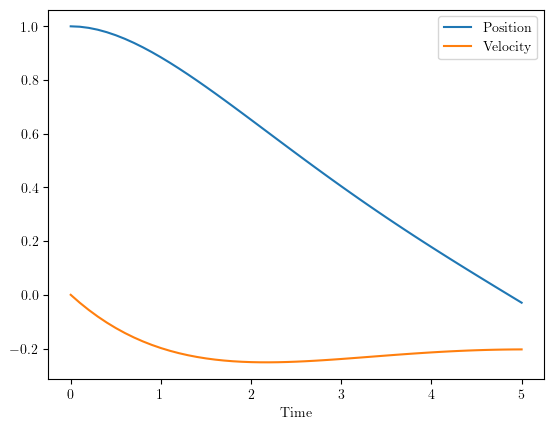

PyObject <matplotlib.legend.Legend object at 0x7f1fb994a350>

In [175]:
# Plot x1 vs. x2, u vs. t, x vs. t, etc.
plot(t_history, x_history[1, :], label = "Position")
plot(t_history, x_history[2, :], label = "Velocity")
xlabel("Time")
legend()

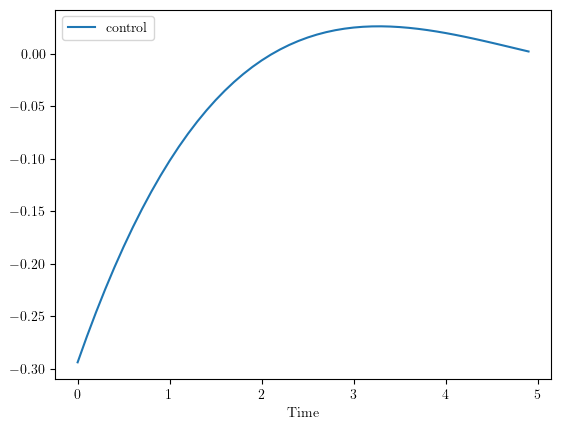

PyObject <matplotlib.legend.Legend object at 0x7f1fb99c2950>

In [176]:
plot(t_history[1:end-1], u_history, label = "control")
xlabel("Time")
legend()